<a href="https://colab.research.google.com/github/septyandini921/SBP_UTS_Model/blob/main/UTS_PBL_SMARTPEAK_NIMAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Library**

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#4C72B0','#DD8452','#55A868','#C44E52']
CHRON_MAP_COLORS = {
    'Lion':'#F4A261', 'Bear':'#2A9D8F', 'Wolf':'#6C63FF', 'Dolphin':'#E9C46A'
}
print("Libraries imported successfully")

Libraries imported successfully


**Load Dataset**

In [31]:
from google.colab import drive
drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/Project/Kuliah/Semester_6/SBP/UTS/study_habits_sample.csv"
df_raw = pd.read_csv(file_path)

print(f"Shape awal: {df_raw.shape}")
df_raw.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape awal: (10000, 12)


,habit_id,student_id,study_hours_weekly,study_location,preferred_study_time,study_method,procrastination_level,organization_level,uses_study_aids,academic_term,academic_year,country
0,NGA_HAB_00075721,NGA_STU_00037734,5.1,Home,Afternoon,Group Study,4.0,3.0,True,Term 3,2023/2024,Nigeria
1,NGA_HAB_00080184,NGA_STU_00068308,NaN,Home,Evening,Note-taking,3.0,3.0,True,Term 3,2023/2024,Nigeria
2,NGA_HAB_00019864,NGA_STU_00043560,4.3,Home,Variable,Practice Problems,5.0,4.0,True,Term 2,2023/2024,Nigeria
3,NGA_HAB_00076699,NGA_STU_00029039,13.8,Home,Evening,Note-taking,3.0,5.0,True,Term 1,2024/2025,Nigeria
4,NGA_HAB_00092991,NGA_STU_00040175,12.3,Home,Afternoon,Note-taking,3.0,2.0,True,Term 3,2023/2024,Nigeria


**EDA**

In [32]:
# Informasi umum dataset
print("=" * 55)
print("INFORMASI UMUM DATASET")
print("=" * 55)
df_raw.info()

INFORMASI UMUM DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   habit_id               10000 non-null  object 
 1   student_id             10000 non-null  object 
 2   study_hours_weekly     9816 non-null   float64
 3   study_location         9901 non-null   object 
 4   preferred_study_time   9912 non-null   object 
 5   study_method           9906 non-null   object 
 6   procrastination_level  9801 non-null   float64
 7   organization_level     9807 non-null   float64
 8   uses_study_aids        10000 non-null  bool   
 9   academic_term          9874 non-null   object 
 10  academic_year          9903 non-null   object 
 11  country                9903 non-null   object 
dtypes: bool(1), float64(3), object(8)
memory usage: 869.3+ KB


In [33]:
# Statistik deskriptif
print("\nStatistik Deskriptif:")
df_raw.describe(include='all').T


Statistik Deskriptif:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
habit_id,10000,10000,NGA_HAB_00023894,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
student_id,10000,9517,NGA_STU_00078002,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
study_hours_weekly,9816.0,NaN,NaN,NaN,8.053535,3.997955,0.4,5.1,7.4,10.3,30.2
study_location,9901,6,Home,3951,NaN,NaN,NaN,NaN,NaN,NaN,NaN
preferred_study_time,9912,5,Evening,2964,NaN,NaN,NaN,NaN,NaN,NaN,NaN
study_method,9906,6,Note-taking,2445,NaN,NaN,NaN,NaN,NaN,NaN,NaN
procrastination_level,9801.0,NaN,NaN,NaN,3.053362,1.110759,1.0,2.0,3.0,4.0,5.0
organization_level,9807.0,NaN,NaN,NaN,3.232691,1.097203,1.0,3.0,3.0,4.0,5.0
uses_study_aids,10000,2,True,6559,NaN,NaN,NaN,NaN,NaN,NaN,NaN
academic_term,9874,3,Term 2,3387,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
# Missing values per kolom
print("Missing Values per Kolom:")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

Missing Values per Kolom:
                       Missing Count  Missing %
study_hours_weekly               184       1.84
study_location                    99       0.99
preferred_study_time              88       0.88
study_method                      94       0.94
procrastination_level            199       1.99
organization_level               193       1.93
academic_term                    126       1.26
academic_year                     97       0.97
country                           97       0.97


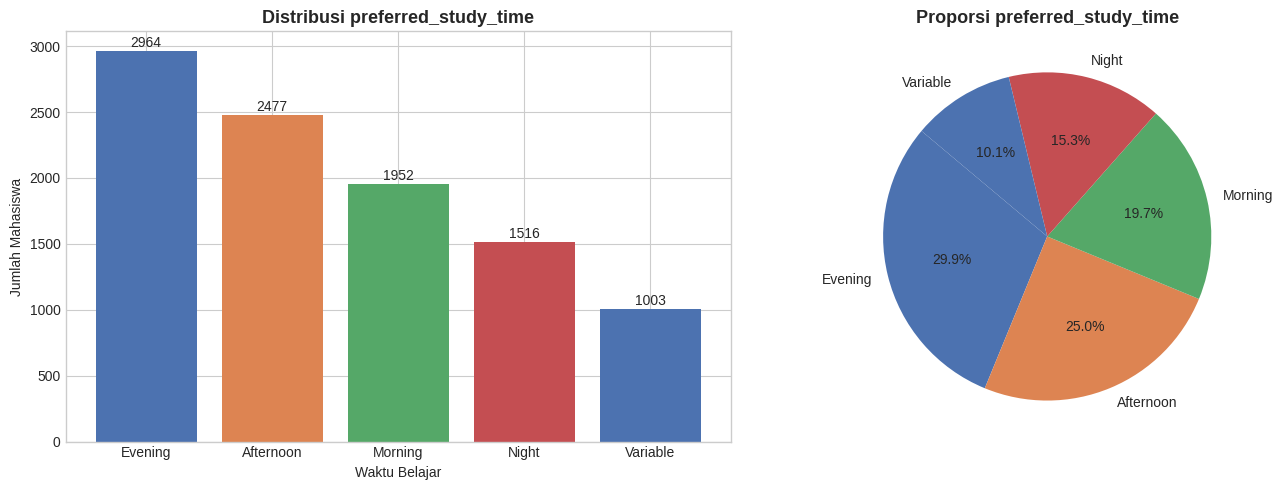


 Catatan: Kolom preferred_study_time akan menjadi DASAR pemberian label chronotype.


In [35]:
# Distribusi variabel
# target: preferred_study_time
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
time_counts = df_raw['preferred_study_time'].value_counts()
axes[0].bar(time_counts.index, time_counts.values, color=COLORS[:len(time_counts)])
axes[0].set_title('Distribusi preferred_study_time', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Waktu Belajar')
axes[0].set_ylabel('Jumlah Mahasiswa')
for i, v in enumerate(time_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=10)

# Pie chart
axes[1].pie(time_counts.values, labels=time_counts.index, autopct='%1.1f%%',
            colors=COLORS[:len(time_counts)], startangle=140)
axes[1].set_title('Proporsi preferred_study_time', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
print("\n Catatan: Kolom preferred_study_time akan menjadi DASAR pemberian label chronotype.")

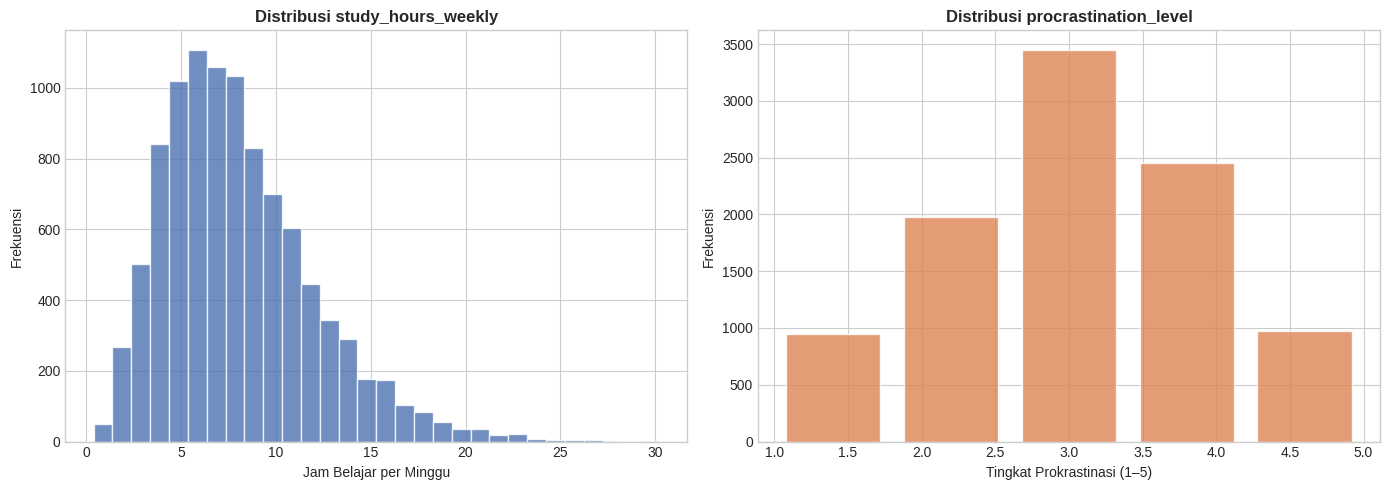

In [36]:
# Distribusi variabel numerik
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_raw['study_hours_weekly'].dropna(), bins=30, color='#4C72B0',
             edgecolor='white', alpha=0.8)
axes[0].set_title('Distribusi study_hours_weekly', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jam Belajar per Minggu')
axes[0].set_ylabel('Frekuensi')

axes[1].hist(df_raw['procrastination_level'].dropna(), bins=5, color='#DD8452',
             edgecolor='white', alpha=0.8, rwidth=0.8)
axes[1].set_title('Distribusi procrastination_level', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tingkat Prokrastinasi (1–5)')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

**Seleksi Fitur**

In [37]:
#Seleksi Fitur
SELECTED_FEATURES = [
    'study_hours_weekly',   # numerik kontinu
    'study_location',       # kategorikal nominal
    'preferred_study_time', # kategorikal ordinal (juga dasar label)
    'study_method',         # kategorikal nominal
    'procrastination_level',# numerik ordinal (1–5)
    'uses_study_aids',       # boolean
    'organization_level'
]

df = df_raw[SELECTED_FEATURES].copy()

print(f"Fitur dipilih: {SELECTED_FEATURES}")
print(f"Shape setelah seleksi fitur: {df.shape}")
df.head(3)

Fitur dipilih: ['study_hours_weekly', 'study_location', 'preferred_study_time', 'study_method', 'procrastination_level', 'uses_study_aids', 'organization_level']
Shape setelah seleksi fitur: (10000, 7)


,study_hours_weekly,study_location,preferred_study_time,study_method,procrastination_level,uses_study_aids,organization_level
0,5.1,Home,Afternoon,Group Study,4.0,True,3.0
1,NaN,Home,Evening,Note-taking,3.0,True,3.0
2,4.3,Home,Variable,Practice Problems,5.0,True,4.0


**Data Cleaning**

In [38]:
#Data Cleaning
print("=" * 55)
print("SEBELUM CLEANING")
print("=" * 55)
print(f"Total baris: {len(df)}")
print(f"Total missing values:\n{df.isnull().sum()}\n")

# Hapus baris duplikat
n_dup = df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(f"Baris duplikat dihapus : {n_dup}")

# Tangani missing values
#     - study_hours_weekly   → isi dengan median (robust terhadap outlier)
#     - procrastination_level→ isi dengan median
#     - study_location       → isi dengan modus
#     - preferred_study_time → HAPUS baris (krusial untuk labeling)
#     - study_method         → isi dengan modus
#     - uses_study_aids      → isi dengan modus

before = len(df)
df.dropna(subset=['preferred_study_time'], inplace=True)
print(f"Baris tanpa preferred_study_time dihapus: {before - len(df)}")

df['study_hours_weekly'].fillna(df['study_hours_weekly'].median(), inplace=True)
df['procrastination_level'].fillna(df['procrastination_level'].median(), inplace=True)
df['study_location'].fillna(df['study_location'].mode()[0], inplace=True)
df['study_method'].fillna(df['study_method'].mode()[0], inplace=True)
df['uses_study_aids'].fillna(df['uses_study_aids'].mode()[0], inplace=True)
df['organization_level'].fillna(df['organization_level'].median(), inplace=True)

print(f"\nMissing values setelah cleaning:")
print(df.isnull().sum())

print(f"\nShape setelah cleaning: {df.shape}")

SEBELUM CLEANING
Total baris: 10000
Total missing values:
study_hours_weekly       184
study_location            99
preferred_study_time      88
study_method              94
procrastination_level    199
uses_study_aids            0
organization_level       193
dtype: int64

Baris duplikat dihapus : 124
Baris tanpa preferred_study_time dihapus: 88

Missing values setelah cleaning:
study_hours_weekly       0
study_location           0
preferred_study_time     0
study_method             0
procrastination_level    0
uses_study_aids          0
organization_level       0
dtype: int64

Shape setelah cleaning: (9788, 7)


In [39]:
#Deteksi & Handling Outlier (study_hours_weekly)
# Metode: IQR (Interquartile Range)
Q1 = df['study_hours_weekly'].quantile(0.25)
Q3 = df['study_hours_weekly'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

n_outlier = ((df['study_hours_weekly'] < lower_bound) |
             (df['study_hours_weekly'] > upper_bound)).sum()

# Winsorize (cap) outlier alih-alih menghapus agar data tidak berkurang banyak
df['study_hours_weekly'] = df['study_hours_weekly'].clip(lower_bound, upper_bound)

print(f"   IQR Outlier Handling — study_hours_weekly")
print(f"   Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
print(f"   Batas bawah: {lower_bound:.2f} | Batas atas: {upper_bound:.2f}")
print(f"   Outlier di-cap (winsorize): {n_outlier} nilai")

   IQR Outlier Handling — study_hours_weekly
   Q1=5.20, Q3=10.20, IQR=5.00
   Batas bawah: -2.30 | Batas atas: 17.70
   Outlier di-cap (winsorize): 240 nilai


**Labeling**

Label Chronotype berhasil di-assign

Distribusi Chronotype:
chronotype
Wolf       4420
Bear       2439
Lion       1933
Dolphin     996
Name: count, dtype: int64


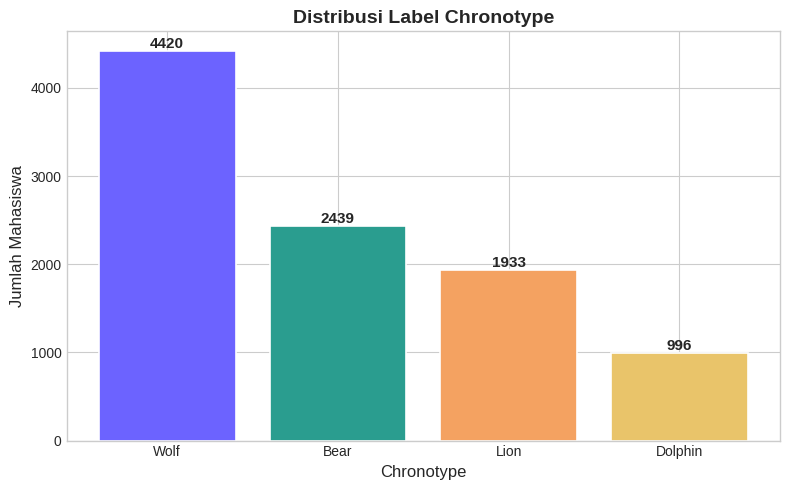


Catatan: Wolf menggabungkan Evening+Night → kemungkinan kelas dominan.


In [40]:
# Label Engineering — Assign CHRONOTYPE
CHRONOTYPE_MAP = {
    'Morning'  : 'Lion',
    'Afternoon': 'Bear',
    'Evening'  : 'Wolf',
    'Night'    : 'Wolf',    # night owl masuk kategori Wolf
    'Variable' : 'Dolphin'
}

df['chronotype'] = df['preferred_study_time'].map(CHRONOTYPE_MAP)

print("Label Chronotype berhasil di-assign")
print("\nDistribusi Chronotype:")
ct_dist = df['chronotype'].value_counts()
print(ct_dist)

# Visualisasi distribusi label
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(ct_dist.index,
              ct_dist.values,
              color=[CHRON_MAP_COLORS[c] for c in ct_dist.index],
              edgecolor='white', linewidth=1.2)
ax.set_title('Distribusi Label Chronotype', fontsize=14, fontweight='bold')
ax.set_xlabel('Chronotype', fontsize=12)
ax.set_ylabel('Jumlah Mahasiswa', fontsize=12)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(int(bar.get_height())), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCatatan: Wolf menggabungkan Evening+Night → kemungkinan kelas dominan.")

**Encoding**

In [41]:
# LANGKAH 5: Transformasi / Encoding
df_model = df.copy()

# 5a. Boolean → int
df_model['uses_study_aids'] = df_model['uses_study_aids'].astype(str).str.strip()
df_model['uses_study_aids'] = df_model['uses_study_aids'].map(
    {'True': 1, 'False': 0, '1': 1, '0': 0}).fillna(0).astype(int)

# 5b. study_hours_weekly → binning kategorik (untuk Forward/Backward Chaining & CF)
df_model['hours_bin'] = pd.cut(
    df_model['study_hours_weekly'],
    bins=[0, 5, 10, 25],
    labels=['Low', 'Medium', 'High']
)

# 5c. procrastination_level → binning
df_model['proc_bin'] = pd.cut(
    df_model['procrastination_level'],
    bins=[0, 2, 3, 5],
    labels=['Low', 'Medium', 'High']
)

# 5d. Label Encoding untuk fitur kategorik (digunakan Naive Bayes & CF)
le_loc   = LabelEncoder()
le_meth  = LabelEncoder()
le_ptime = LabelEncoder()
le_chron = LabelEncoder()
le_hbin  = LabelEncoder()
le_pbin  = LabelEncoder()

df_model['loc_enc']    = le_loc.fit_transform(df_model['study_location'])
df_model['meth_enc']   = le_meth.fit_transform(df_model['study_method'])
df_model['ptime_enc']  = le_ptime.fit_transform(df_model['preferred_study_time'])
df_model['chron_enc']  = le_chron.fit_transform(df_model['chronotype'])
df_model['hbin_enc']   = le_hbin.fit_transform(df_model['hours_bin'])
df_model['pbin_enc']   = le_pbin.fit_transform(df_model['proc_bin'])

print(" Encoding selesai")
print("\nMapping Chronotype:")
for i, cls in enumerate(le_chron.classes_):
    print(f"  {i} → {cls}")

print("\nPreview df_model:")
df_model[['study_hours_weekly','hours_bin','procrastination_level','proc_bin',
          'study_location','study_method','uses_study_aids','preferred_study_time',
          'chronotype','chron_enc']].head()


 Encoding selesai

Mapping Chronotype:
  0 → Bear
  1 → Dolphin
  2 → Lion
  3 → Wolf

Preview df_model:


,study_hours_weekly,hours_bin,procrastination_level,proc_bin,study_location,study_method,uses_study_aids,preferred_study_time,chronotype,chron_enc
0,5.1,Medium,4.0,High,Home,Group Study,1,Afternoon,Bear,0
1,7.4,Medium,3.0,Medium,Home,Note-taking,1,Evening,Wolf,3
2,4.3,Low,5.0,High,Home,Practice Problems,1,Variable,Dolphin,1
3,13.8,High,3.0,Medium,Home,Note-taking,1,Evening,Wolf,3
4,12.3,High,3.0,Medium,Home,Note-taking,1,Afternoon,Bear,0


**Certainty Factor Engine**
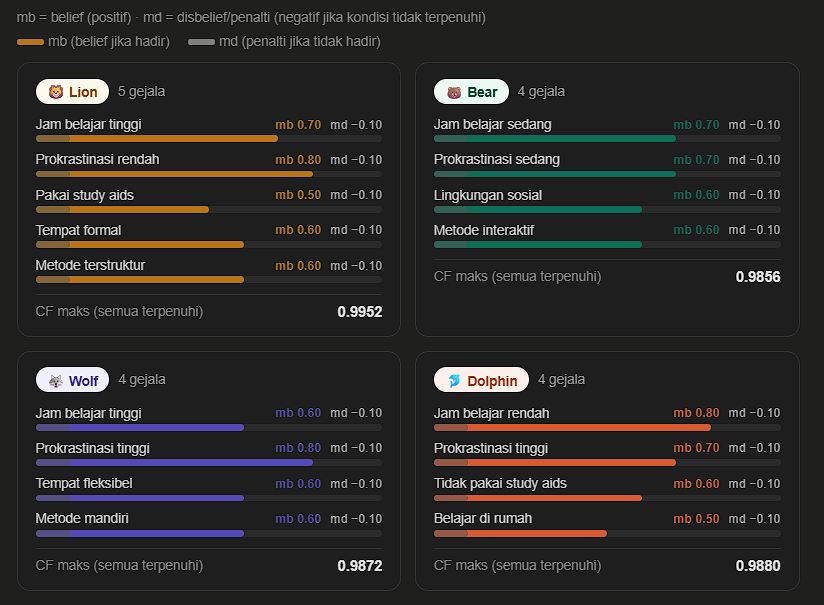

In [42]:
# Knowledge base
CF_RULES = {
    'Lion': [
        (lambda r: r['hours_bin'] == 'High',               0.7, 0.1, 'Jam tinggi'),
        (lambda r: r['proc_bin'] == 'Low',                 0.8, 0.1, 'Prokrastinasi rendah'),
        (lambda r: r['uses_study_aids'] == 1,              0.5, 0.1, 'Pakai aids'),
        (lambda r: r['study_location'] in ['Library','Classroom'], 0.6, 0.1, 'Tempat formal'),
        (lambda r: r['study_method'] in ['Reading','Note-taking'], 0.6, 0.1, 'Metode terstruktur'),
    ],

    'Bear': [
        (lambda r: r['hours_bin'] == 'Medium',             0.7, 0.1, 'Jam sedang'),
        (lambda r: r['proc_bin'] == 'Medium',              0.7, 0.1, 'Prokrastinasi sedang'),
        (lambda r: r['study_location'] in ['Classroom','Study Group'], 0.6, 0.1, 'Lingkungan sosial'),
        (lambda r: r['study_method'] in ['Group Study','Flashcards'], 0.6, 0.1, 'Metode interaktif'),
    ],

    'Wolf': [
        (lambda r: r['hours_bin'] == 'High',               0.6, 0.1, 'Jam tinggi'),
        (lambda r: r['proc_bin'] == 'High',                0.8, 0.1, 'Prokrastinasi tinggi'),
        (lambda r: r['study_location'] in ['Home','Cafe'], 0.6, 0.1, 'Tempat fleksibel'),
        (lambda r: r['study_method'] in ['Practice Problems','Video Tutorials'], 0.6, 0.1, 'Mandiri'),
    ],

    'Dolphin': [
        (lambda r: r['hours_bin'] == 'Low',                0.8, 0.1, 'Jam rendah'),
        (lambda r: r['proc_bin'] == 'High',                0.7, 0.1, 'Prokrastinasi tinggi'),
        (lambda r: r['uses_study_aids'] == 0,              0.6, 0.1, 'Tidak pakai aids'),
        (lambda r: r['study_location'] == 'Home',          0.5, 0.1, 'Di rumah'),
    ]
}

1. CF per Rule$$CF_{rule} = MB(H, E) \quad \text{jika kondisi terpenuhi}$$$$CF_{rule} = -MD(H, E) \quad \text{jika kondisi tidak terpenuhi}$$

2. Kombinasi CF$$CF_{combine} = CF_{prev} + CF_{rule} \times (1 - CF_{prev})$$


3. Prediksi$$Prediksi = \arg\max(CF_{class})$$

4. Keterangan$$MB(H, E) \in [0, 1], \quad MD(H, E) \in [0, 1], \quad CF \in [-1, 1]$$

In [43]:
# Hitung CF
def calculate_cf(row, rules, verbose=False):
    results = {}
    detail = {}

    for chrono, conditions in rules.items():
        cf_total = 0
        first = True
        fired_rules = []

        for cond_fn, mb, md, desc in conditions:

            # kalau kondisi terpenuhi → positif
            if cond_fn(row):
                cf_rule = mb
                fired_rules.append((desc, f"+{round(cf_rule,3)}"))

            # kalau TIDAK terpenuhi → penalti
            else:
                cf_rule = -md
                fired_rules.append((f"Tidak {desc}", f"{round(cf_rule,3)}"))

            # kombinasi CF
            if first:
                cf_total = cf_rule
                first = False
            else:
                cf_total = cf_total + cf_rule * (1 - cf_total)

        results[chrono] = round(cf_total, 4)
        detail[chrono] = fired_rules

    if verbose:
        return results, detail
    return results

In [44]:
# Demo 1 Data
sample = df_model.iloc[0]

cf_result, cf_detail = calculate_cf(sample, CF_RULES, verbose=True)

# ambil prediksi
prediction = max(cf_result, key=cf_result.get)

# ambil label asli
actual = sample['chronotype']

print("HASIL CF (1 DATA):")
for k, v in cf_result.items():
    print(f"{k}: {v}")

print("\nRULE YANG TERPICU:")
for chrono, rules in cf_detail.items():
    print(f"\n{chrono}:")
    for r in rules:
        print(f" - {r[0]} (CF={r[1]})")

print("\nLabel Asli :", actual)
print("Prediksi   :", prediction)

# cek benar / salah
if prediction == actual:
    print("HASIL: BENAR")
else:
    print("HASIL: SALAH")

HASIL CF (1 DATA):
Lion: 0.2679
Bear: 0.8548
Wolf: 0.9032
Dolphin: 0.8185

RULE YANG TERPICU:

Lion:
 - Tidak Jam tinggi (CF=-0.1)
 - Tidak Prokrastinasi rendah (CF=-0.1)
 - Pakai aids (CF=+0.5)
 - Tidak Tempat formal (CF=-0.1)
 - Tidak Metode terstruktur (CF=-0.1)

Bear:
 - Jam sedang (CF=+0.7)
 - Tidak Prokrastinasi sedang (CF=-0.1)
 - Tidak Lingkungan sosial (CF=-0.1)
 - Metode interaktif (CF=+0.6)

Wolf:
 - Tidak Jam tinggi (CF=-0.1)
 - Prokrastinasi tinggi (CF=+0.8)
 - Tempat fleksibel (CF=+0.6)
 - Tidak Mandiri (CF=-0.1)

Dolphin:
 - Tidak Jam rendah (CF=-0.1)
 - Prokrastinasi tinggi (CF=+0.7)
 - Tidak Tidak pakai aids (CF=-0.1)
 - Di rumah (CF=+0.5)

Label Asli : Bear
Prediksi   : Wolf
HASIL: SALAH


**Evaluasi**

In [45]:
# Evaluasi Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# ── Split data ──────────────────────────────────────────────────
X = df_model.copy()
y = df_model['chronotype']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Prediksi CF ────────────────────────────────────────────────
cf_predictions = []
cf_scores_all = []

for _, row in X_test.iterrows():
    cf_dict = calculate_cf(row, CF_RULES)

    best_class = max(cf_dict, key=cf_dict.get)

    cf_predictions.append(best_class)
    cf_scores_all.append(cf_dict)

# ── Evaluasi ───────────────────────────────────────────────────
accuracy = accuracy_score(y_test, cf_predictions)
print(f"Accuracy CF: {accuracy:.4f}")
print(f"Accuracy CF (%): {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, cf_predictions))

Accuracy CF: 0.2411
Accuracy CF (%): 24.11%

Classification Report:
              precision    recall  f1-score   support

        Bear       0.25      0.27      0.26       488
     Dolphin       0.12      0.20      0.15       199
        Lion       0.19      0.38      0.26       387
        Wolf       0.45      0.18      0.25       884

    accuracy                           0.24      1958
   macro avg       0.25      0.25      0.23      1958
weighted avg       0.32      0.24      0.24      1958



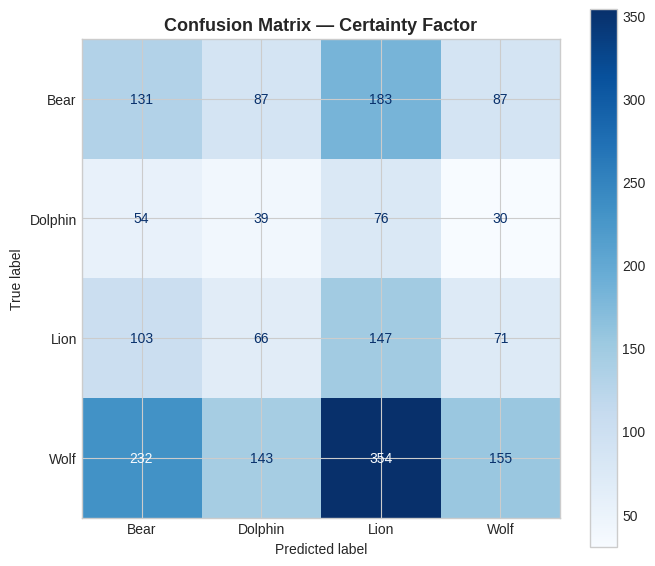

In [46]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 6))

# pastikan label urut & konsisten
classes_cf = sorted(y_test.unique())

cm_cf = confusion_matrix(
    y_test,
    cf_predictions,
    labels=classes_cf
)

ConfusionMatrixDisplay(
    confusion_matrix=cm_cf,
    display_labels=classes_cf
).plot(ax=ax, cmap='Blues', colorbar=True)

ax.set_title('Confusion Matrix — Certainty Factor',
             fontsize=13,
             fontweight='bold')

plt.tight_layout()
plt.show()

In [47]:
# ── RATA-RATA CF PER CHRONOTYPE ────────────────────────────────
from collections import defaultdict

cf_avg = defaultdict(list)

for cf_dict in cf_scores_all:
    for k, v in cf_dict.items():
        cf_avg[k].append(v)

print("\n📈 Rata-rata CF per Chronotype:")
for k in cf_avg:
    print(f"{k}: {np.mean(cf_avg[k]):.4f}")


📈 Rata-rata CF per Chronotype:
Lion: 0.6679
Bear: 0.5105
Wolf: 0.4803
Dolphin: 0.4483
